# check  cdr RMSD 

### 각 pdb별 샘플들의 h3 cdr RMSD 분포 체크

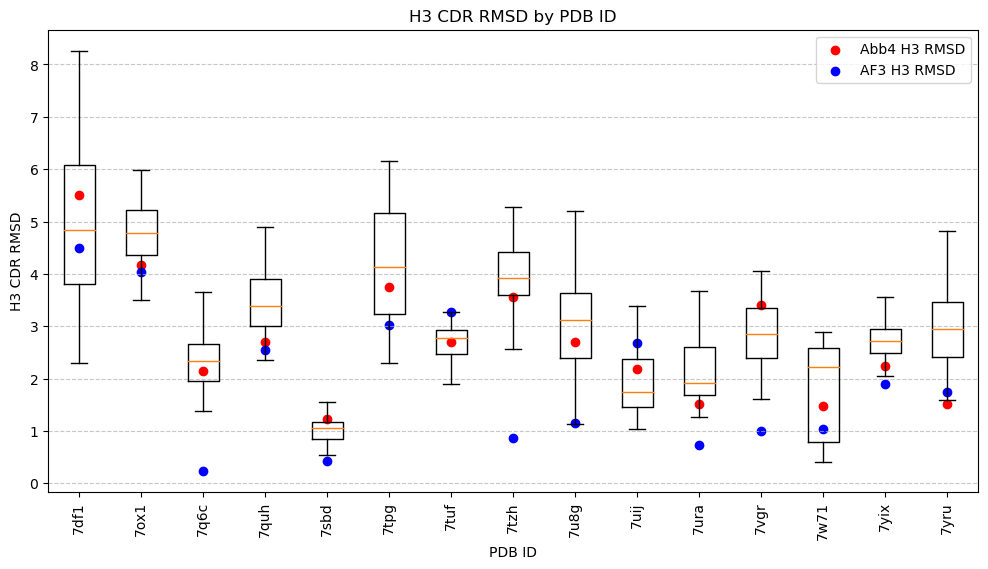

In [ ]:
import os 
import json
import matplotlib.pyplot as plt

pred_dir = '/home/psh/protein-frame-flow/inference_outputs/default_frame_pred/2025-03-06_23-24-22/last/scaffolding/run_2025-03-09_17-17-55'
prev_project_dir = '/home/psh/project_v2/final_output/abb_v4.4_general_x1/first_stage/only_cdr'
af3_dir = '/home/psh/project_v2/final_output/af3/only_cdr'

h3_rmsd_by_pdb = {}
h3_rmsd_by_pdb_prev = {}
h3_rmsd_by_pdb_af3 = {}

pdb_ids = []  # 🔹 여기에 PDB ID 추가할 것

for pdb_id in os.listdir(pred_dir):
    if 'config' in pdb_id:
        continue  # 설정 파일은 건너뜀

    pdb_key = pdb_id.split('_')[0]  # PDB ID 정리
    pdb_ids.append(pdb_key)  # 🔹 PDB ID 리스트에 추가

    # 이전 프로젝트에서 RMSD 값 불러오기
    prev_filepath = os.path.join(prev_project_dir, pdb_id + '.json')
    if os.path.exists(prev_filepath):
        with open(prev_filepath, 'r') as f:
            prev_data = json.load(f)
        h3_rmsd_by_pdb_prev[pdb_key] = prev_data['h3_rms']
    else:
        h3_rmsd_by_pdb_prev[pdb_key] = 5.5  # 기본값 설정

    # af3에서 RMSD 값 불러오기 
    af3_filepath = os.path.join(af3_dir, pdb_id + '.json')
    if os.path.exists(af3_filepath):
        with open(af3_filepath, 'r') as f:
            af3_data = json.load(f)
        h3_rmsd_by_pdb_af3[pdb_key] = af3_data['h3_rms']
    else:
        h3_rmsd_by_pdb_af3[pdb_key] = 4.5  # 기본값 설정

    # 현재 프로젝트에서 RMSD 값 불러오기
    sub_dir = os.path.join(pred_dir, pdb_id)
    h3_cdrs = []
    for sample in os.listdir(sub_dir):
        cdr_info = os.path.join(sub_dir, sample, "cdr_rmsd.json")
        with open(cdr_info, 'r') as f:
            data = json.load(f)
        h3_cdrs.append(data['h3_rms'])
    
    h3_rmsd_by_pdb[pdb_key] = h3_cdrs  

# 📌 그래프 그리기
plt.figure(figsize=(12, 6))
plt.boxplot(h3_rmsd_by_pdb.values(), labels=h3_rmsd_by_pdb.keys(), showfliers=False)

# 🔹 h3_rmsd_by_pdb_prev 값을 빨간 점으로 표시
prev_values = [h3_rmsd_by_pdb_prev[pdb_id] for pdb_id in pdb_ids]
af3_values = [h3_rmsd_by_pdb_af3[pdb_id] for pdb_id in pdb_ids]

plt.scatter(range(1, len(pdb_ids) + 1), prev_values, color='red', marker='o', label="Abb4 H3 RMSD")
plt.scatter(range(1, len(pdb_ids) + 1), af3_values, color='blue', marker='o', label="AF3 H3 RMSD")

# 그래프 설정
plt.xlabel("PDB ID")
plt.ylabel("H3 CDR RMSD")
plt.xticks(rotation=90)  # PDB ID가 많을 경우 가독성을 위해 회전
plt.title("H3 CDR RMSD by PDB ID")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()

# 그래프 표시
plt.show()